In [3]:
# General imports
from netsim.netSimPy import *
from netsim.netSimPy.common.evaluators import NetworkEvaluator
from netsim.netSimPy.common.allocators import alphaBalancing

In [4]:
import itertools

# available_bands = [["C", "L", "S", "E"], ["E", "S", "L", "C"]]
# simulators = {}
# for alpha in range(0,11,1):
N_EVALUATIONS = 500000

available_bands = ["C", "S", "L", "E"]
traffics = [150000, 200000, 250000, 300000, 350000, 400000]
alphas = [0.3, 0.4, 0.5, 0.6, 0.7]
# alphas = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.2, 0.1, 1]
simulators = {}


for alpha in alphas:
    for bands1 in list(itertools.permutations(available_bands)):
        for bands2 in list(itertools.permutations(available_bands)):
            if (
                list(bands1) == ["C", "L", "S", "E"]
                or list(bands1) == ["E", "S", "L", "C"]
            ) and (
                list(bands2) == ["C", "L", "S", "E"]
                or list(bands2) == ["E", "S", "L", "C"]
            ):
                allocator = alphaBalancing(1, [alpha, 1], [bands1, bands2])
                network = Network(
                    networkFileName="../../../networks/nsfnet/network.json",
                    pathsFileName="../../../networks/nsfnet/routes.json",
                    bitrateFilename="../../../networks/nsfnet/bitrates_4_bands.json",
                )

                generator = EventsGenerator(10000)
                sim_args1 = dict(
                    eventsGenerator=generator,
                    network=network,
                    allocator=allocator,
                )
                simulator = NetworkSimulator(**sim_args1)
                name = "".join(bands1) + "_" + "".join(bands2) + "_" + f"{alpha}"
                # for traffic in traffics:
                #     callback = NetworkEvaluator(f"{name}_{int(traffic/100)}")
                #     simulator.reset()
                #     simulator.setLambda(traffic)
                #     print(f"Running simulation for {name} with lambda: {traffic/100}")
                #     simulator.run(N_EVALUATIONS, callback)
                #     print("\n")

In [5]:
from typing import Any
import pandas as pd
import ast
from pathlib import Path
import glob


def read_csv(path: Path):
    # Read the CSV, skip the first comment line
    df = pd.read_csv(path.resolve(), comment="#")
    # Take the first row and convert it to a dict (columns become keys)
    row_dict = df.iloc[0].to_dict()
    # Try to parse each value that looks like a dictionary
    for key, value in row_dict.items():
        if isinstance(value, str) and value.strip().startswith(("{", "[")):
            try:
                row_dict[key] = ast.literal_eval(value)
            except Exception:
                pass  # Leave as-is if not safely parsable
    return row_dict

In [6]:
results: dict[str, list[dict[str, Any]]] = {}
loads = {}
orders = {}

for file in glob.glob("./*.csv"):
    path = Path(file)
    name = path.name
    order0, order1, alpha, load = name.split("net.evaluations")[0].split("_")

    if not alpha in results:
        results[alpha] = {}
    try:
        csv = read_csv(path)
        order = f"{order0}-{order1}"
        csv["load"] = load
        if order not in results[alpha]:
            results[alpha][order] = []
        results[alpha][order].append(csv)
    except Exception:
        pass

In [ ]:
# Diferencia porcentual
import matplotlib.pyplot as plt

block_prob: dict[str, list[tuple[str, float]]] = {}


for key, data in results.items():
    # key = "0.3"
    # data = results["0.3"]

    plt.figure(figsize=(10, 6))

    for order_key, order_data in data.items():

        valor_clse = data["CLSE-CLSE"]
        pb = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in valor_clse
        ]
        pb_ordenados = sorted(pb, key=lambda p: p[0])
        # if order_key == "ESLC-ESLC":
        #     continue
        pares = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in order_data
        ]

        # Ordenar por el valor de x
        pares_ordenados = sorted(pares, key=lambda p: p[0])
        for ind, ((pb_x, pb_y), (pa_x, pa_y)) in enumerate(
            zip(pb_ordenados, pares_ordenados)
        ):
            if pb_y == 0:
                pares_ordenados[ind] = 0
            else:
                pares_ordenados[ind] = (pa_x, (pa_y - pb_y) * 100 / pb_y)
        # Separar los ejes ordenados
        eje_x = [x for x, y in pares_ordenados]
        eje_y = [y for x, y in pares_ordenados]

        plt.plot(eje_x, eje_y, label=order_key)
        plt.legend()
    # labels = [csv["order"] for csv in data if csv[]]
    # plt.scatter(eje_x, eje_y, color="blue")
    plt.margins(y=0.1)
    # Etiquetas y título
    plt.xlabel("Carga de tráfico")
    plt.ylabel(f"Probabilidad de bloqueo para alpha={key}")
    plt.title("Diferencia de PB vs Carga de tráfico")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

ZeroDivisionError: float division by zero

<Figure size 1000x600 with 0 Axes>

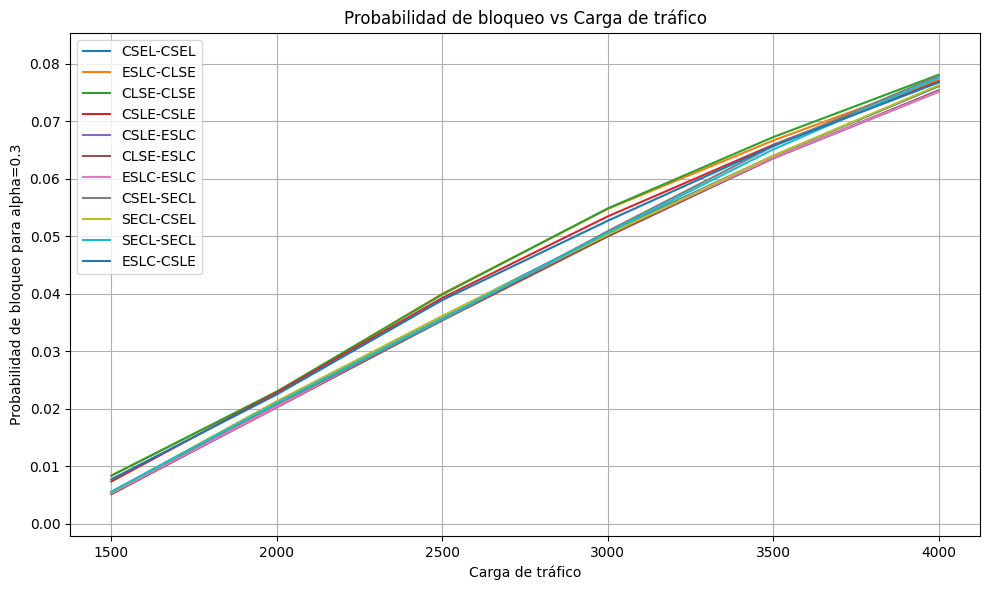

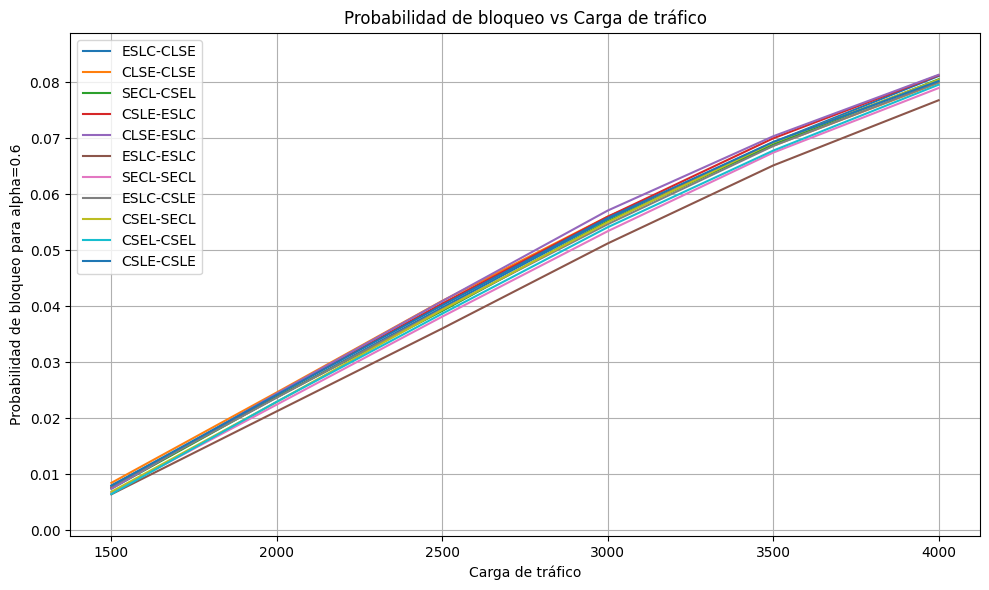

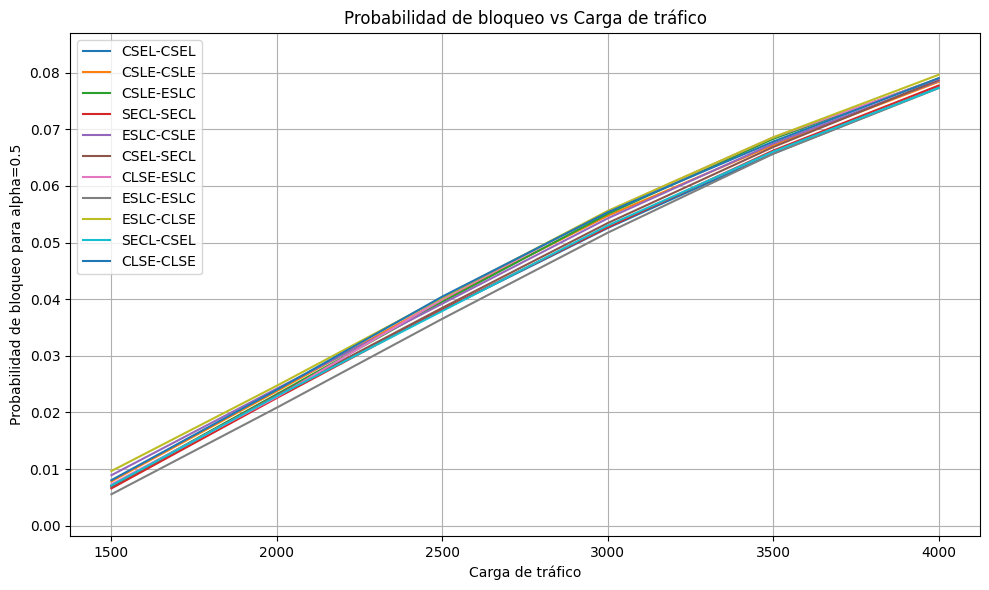

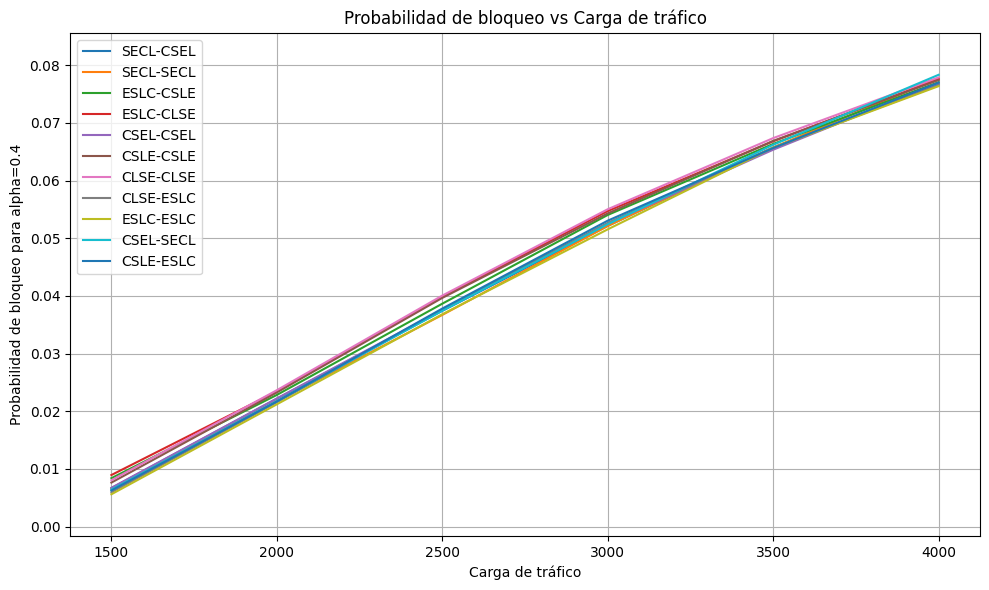

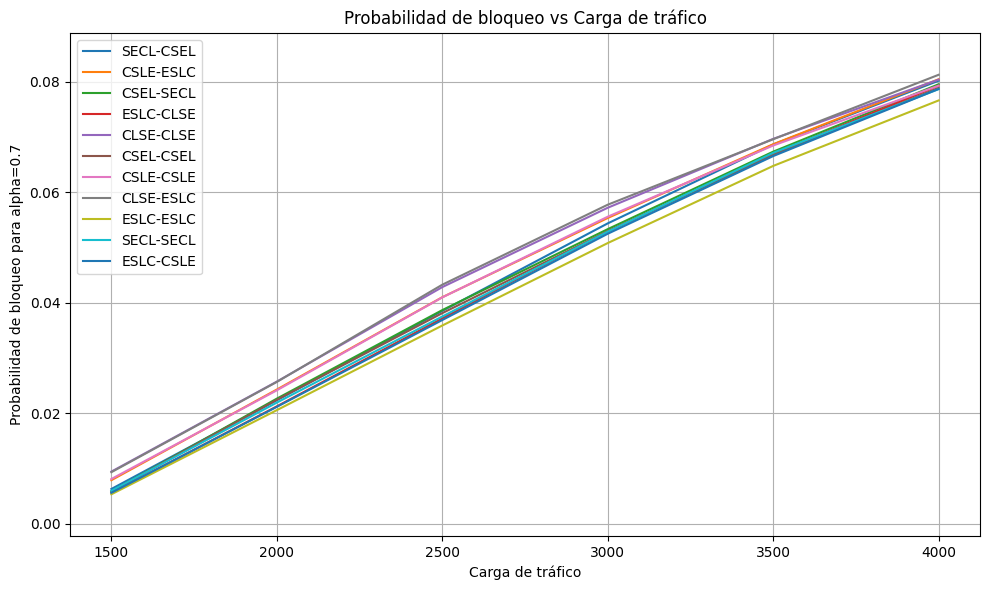

In [ ]:
import matplotlib.pyplot as plt

block_prob: dict[str, list[tuple[str, float]]] = {}


for key, data in results.items():
    # key = "0.3"
    # data = results["0.3"]

    plt.figure(figsize=(10, 6))

    for order_key, order_data in data.items():
        pares = [
            (float(csv["load"]), csv["blockedEvents"] / (csv["steps"]))
            for csv in order_data
        ]

        # Ordenar por el valor de x
        pares_ordenados = sorted(pares, key=lambda p: p[0])
        # Separar los ejes ordenados
        eje_x = [x for x, y in pares_ordenados]
        eje_y = [y for x, y in pares_ordenados]

        plt.plot(eje_x, eje_y, label=order_key)
        plt.legend()
    # labels = [csv["order"] for csv in data if csv[]]
    # plt.scatter(eje_x, eje_y, color="blue")
    plt.margins(y=0.1)
    # Etiquetas y título
    plt.xlabel("Carga de tráfico")
    plt.ylabel(f"Probabilidad de bloqueo para alpha={key}")
    plt.title("Probabilidad de bloqueo vs Carga de tráfico")
    plt.grid(True)
    plt.tight_layout()
    plt.show()